# Embeddings and Latent Space

We will inspect a lookup, follow its gradient, train a small category map, retrieve neighbors, and learn an encoder–decoder bottleneck. The group labels deliberately supply the toy word relationships. All data are local, and all calculations run on CPU.

## Start with the problem this lesson solves

A category ID identifies an item but does not describe similarity. If apple, pear, and car have IDs zero, one, and two, arithmetic on those IDs does not tell us that apple and pear should be related. An embedding learns a vector for each category so a downstream task can use meaningful numerical relationships.

A feature-based encoder solves a related problem: compute a useful internal representation for an input, including a new input whose features are available. Both are ways an ANN can represent information; a lookup stores vectors, while an encoder calculates them.

## Follow lookup, comparison, learning, and compression

**Look up a category.** Let the embedding table's rows be apple $[1,0]$, pear $[0.8,0.6]$, and car $[-1,0]$. Pear's ID one selects the second row. Multiplying one-hot vector $[0,1,0]$ by the table does the same thing: $0[1,0]+1[0.8,0.6]+0[-1,0]=[0.8,0.6]$. The ID is an address, not a continuous measurement.

**Compare two vectors.** Apple and pear have dot product $1(0.8)+0(0.6)=0.8$. Their lengths are $\sqrt{1^2+0^2}=1$ and $\sqrt{0.8^2+0.6^2}=1$. Cosine similarity is dot product divided by the product of lengths, so it is $0.8$. Pear and car have cosine $-0.8$. Among those two candidates, apple is therefore pear's nearest neighbor by cosine. These are chosen vectors; useful relationships must come from training data in a learned system.

**Change a selected row.** To expose learning, temporarily give pear target vector $t=[1,0]$ and loss $L=\tfrac12\|E_1-t\|^2$. Error is $[-0.2,0.6]$. Squared errors are $[0.04,0.36]$, so $L=\tfrac12(0.4)=0.2$. The gradient is $E_1-t=[-0.2,0.6]$.

At SGD rate $0.1$, the new pear row is $[0.8,0.6]-0.1[-0.2,0.6]=[0.82,0.54]$. New error is $[-0.18,0.54]$, and new loss is $\tfrac12(0.0324+0.2916)=0.162$. The other two rows receive zero gradient from this single lookup. A downstream task would normally supply the learning signal instead of this hand-written vector target.

**Compute a representation rather than retrieving it.** Here is a separate, exactly solvable linear encoder–decoder miniature. Suppose clean sensors report $x=[u,v,u+v,u-v]$. For hidden factors $u=2,v=1$, readings are $[2,1,3,1]$. An encoder that selects the first two readings computes $z=[2,1]$. A decoder computes $[z_1,z_2,z_1+z_2,z_1-z_2]=[2,1,3,1]$. All four reconstruction errors are zero, so MSE is zero.

Four recorded numbers needed only two independent values in this constructed process. The real companion learns a linear bottleneck from noisy, standardized data; it is not given this hand-built encoder and should not be expected to reconstruct noise perfectly.

## Why a learned representation helps

A useful embedding lets a model compare categories and reuse relationships instead of treating every ID as unrelated. A bottleneck can preserve important structure while reducing the number of values passed onward. Reconstruction error teaches the encoder which information the decoder needs.

Similarity depends on the training objective; an embedding does not inherently know the meaning of a word. A lookup has no learned row for an unseen ID. An encoder can process new feature vectors, but usefulness still depends on how representative training was. A linear autoencoder is closely related to PCA, so reconstruction success alone does not establish a neural-network advantage over that simpler method.

## Connect the explanation to the code

`nn.Embedding` indexes rows of a parameter table. `F.cosine_similarity` divides a dot product by vector lengths. The selected-row example isolates a lookup gradient; the later pair loss learns supplied category relationships. The encoder and decoder are `nn.Linear` modules whose weights learn compression and reconstruction together. Training-only standardization and a held-out reconstruction baseline keep the final comparison interpretable.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

In [1]:
import copy
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(12)
torch.set_num_threads(1)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## Work through lookup and similarity

Rows are apple, pear, and car. The pear ID selects the second row. Its cosine similarity with apple is 0.8 because both vectors have unit norm.

In [2]:
table = torch.tensor([[1., 0.], [0.8, 0.6], [-1., 0.]])
ids = torch.tensor([1, 0, 1, 2])
lookup = torch.nn.Embedding.from_pretrained(table.clone(), freeze=False)
one_hot = F.one_hot(ids, num_classes=3).float()
torch.testing.assert_close(lookup(ids), one_hot @ lookup.weight)
a, p = table[0], table[1]
manual_cosine = (a @ p) / (a.norm() * p.norm())
torch.testing.assert_close(manual_cosine, F.cosine_similarity(a[None], p[None]).squeeze())
torch.testing.assert_close(manual_cosine, torch.tensor(0.8))
torch.testing.assert_close(F.cosine_similarity(a[None], (2*p)[None]).squeeze(), manual_cosine)
print('Batch lookup shape:', tuple(lookup(ids).shape))
print('Pear vector:', lookup(torch.tensor(1)).detach().tolist())
print('Cosine apple/pear:', round(manual_cosine.item(), 3))
print('Dot products before/after doubling pear:', (a @ p).item(), (a @ (2*p)).item())

Batch lookup shape: (4, 2)
Pear vector: [0.800000011920929, 0.6000000238418579]
Cosine apple/pear: 0.8
Dot products before/after doubling pear: 0.800000011920929 1.600000023841858


## Watch a gradient update one row

For this arithmetic example only, pear aims at `[1, 0]`. The half-squared-error gradient is `[-0.2, 0.6]`. Plain SGD with rate 0.1 should move it to `[0.82, 0.54]`. Default embedding gradients are dense.

In [3]:
before = lookup.weight.detach().clone()
stepper = torch.optim.SGD(lookup.parameters(), lr=0.1)
stepper.zero_grad(set_to_none=True)
row_loss = 0.5 * (lookup(torch.tensor(1)) - torch.tensor([1., 0.])).square().sum()
row_loss.backward()
expected_gradient = torch.tensor([[0., 0.], [-0.2, 0.6], [0., 0.]])
torch.testing.assert_close(lookup.weight.grad, expected_gradient)
print('Loss:', round(row_loss.item(), 3))
print('Dense gradient matrix:\n', lookup.weight.grad)
assert not lookup.weight.grad.is_sparse
stepper.step()
torch.testing.assert_close(lookup.weight[1], torch.tensor([0.82, 0.54]))
torch.testing.assert_close(lookup.weight.detach()[[0, 2]], before[[0, 2]])
print('Updated pear:', lookup.weight[1].detach().tolist())

Loss: 0.2
Dense gradient matrix:
 tensor([[ 0.0000,  0.0000],
        [-0.2000,  0.6000],
        [ 0.0000,  0.0000]])
Updated pear: [0.8199999928474426, 0.5400000214576721]


## Train all same-group and different-group pairs

The positive term is mean `(1 - cosine)`. The negative term is mean `relu(cosine - margin)`, with margin −0.2. Each set is averaged separately. This teaches the supplied category relationships, not general language semantics.

In [4]:
torch.manual_seed(12)
words = ['apple', 'pear', 'car', 'bus', 'rose', 'tulip']
groups = torch.tensor([0, 0, 1, 1, 2, 2])
embedding = torch.nn.Embedding(len(words), 2)
initial = embedding.weight.detach().clone()
pairs = torch.combinations(torch.arange(len(words)), r=2)
same = groups[pairs[:, 0]] == groups[pairs[:, 1]]
margin = -0.2

def pair_scores(weights):
    return F.cosine_similarity(weights[pairs[:, 0]], weights[pairs[:, 1]], dim=1)

def embedding_loss(weights):
    scores = pair_scores(weights)
    return (1 - scores[same]).mean() + F.relu(scores[~same] - margin).mean()

optimizer = torch.optim.Adam(embedding.parameters(), lr=0.04)
loss_history = []
for epoch in range(400):
    optimizer.zero_grad(set_to_none=True)
    loss = embedding_loss(embedding.weight)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        loss_history.append(embedding_loss(embedding.weight).item())

learned = embedding.weight.detach().clone()
# Recompute using the final weights, after the last optimizer update.
with torch.no_grad():
    for label, weights in [('Initial', initial), ('Trained', learned)]:
        scores = pair_scores(weights)
        print(f'{label}: same-group mean={scores[same].mean():.4f}, different-group mean={scores[~same].mean():.4f}')
assert loss_history[-1] < embedding_loss(initial).item()
assert pair_scores(learned)[same].mean() > pair_scores(learned)[~same].mean()
print('Final loss:', loss_history[-1])

Initial: same-group mean=-0.5053, different-group mean=-0.0229
Trained: same-group mean=1.0000, different-group mean=-0.4957
Final loss: 3.973643103449831e-08


## Compare directions before and after training

Normalize the vectors for this plot because the loss constrains directions, not lengths. Every point lies on the unit circle. Axis coordinates have no fixed semantic meaning.

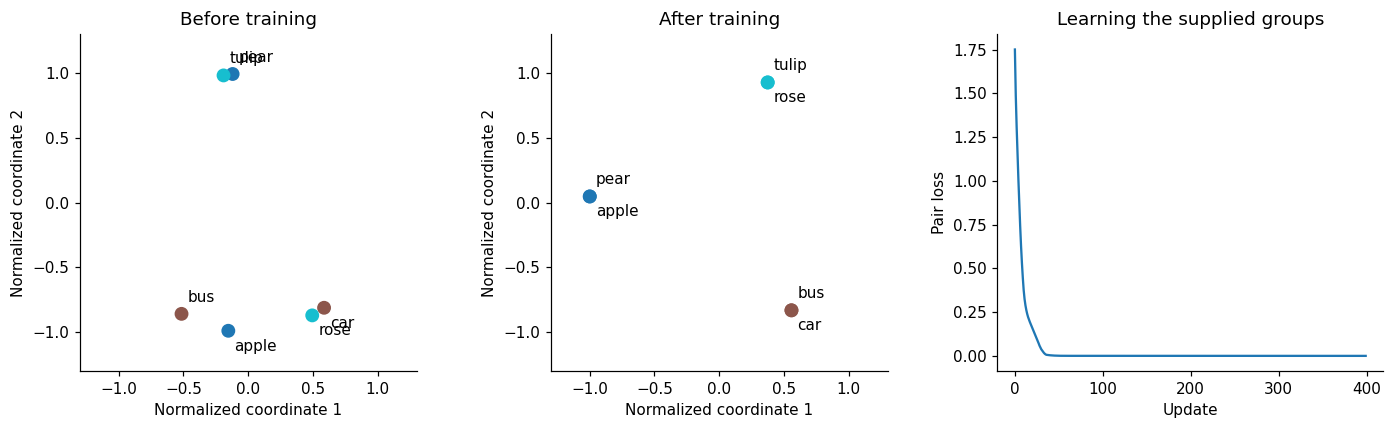

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, weights, title in zip(axes[:2], [initial, learned], ['Before training', 'After training']):
    points = F.normalize(weights, dim=1).numpy()
    ax.scatter(points[:, 0], points[:, 1], c=groups, cmap='tab10', s=65)
    for i, word in enumerate(words):
        ax.annotate(word, points[i], xytext=(4, 8 if i % 2 else -13), textcoords='offset points')
    ax.set(xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), xlabel='Normalized coordinate 1', ylabel='Normalized coordinate 2', title=title)
    ax.set_aspect('equal')
axes[2].plot(loss_history)
axes[2].set(xlabel='Update', ylabel='Pair loss', title='Learning the supplied groups')
fig.tight_layout()
plt.show()

## Retrieve the nearest other category

Normalized dot products give cosine scores. Exclude self-matches before taking the maximum. These are training-category checks, not held-out retrieval results.

In [6]:
normalized = F.normalize(learned, dim=1)
similarity = normalized @ normalized.T
similarity.fill_diagonal_(-torch.inf)
neighbors = similarity.argmax(dim=1)
for i, neighbor in enumerate(neighbors.tolist()):
    print(f'{words[i]:5s} -> {words[neighbor]:5s} (cosine {similarity[i, neighbor]:.3f})')
assert torch.equal(groups[neighbors], groups)
print('All six nearest neighbors match the supplied groups.')

apple -> pear  (cosine 1.000)
pear  -> apple (cosine 1.000)
car   -> bus   (cosine 1.000)
bus   -> car   (cosine 1.000)
rose  -> tulip (cosine 1.000)
tulip -> rose  (cosine 1.000)
All six nearest neighbors match the supplied groups.


## Generate four sensors from two hidden factors

Now learn a latent representation from features rather than category IDs. Independent data splits come from the same synthetic process. Only training data determine scaling. The model never receives the hidden generating factors.

In [7]:
generator = torch.Generator().manual_seed(120)
def make_sensors(count):
    factors = torch.randn(count, 2, generator=generator)
    u, v = factors[:, 0], factors[:, 1]
    clean = torch.stack([u, v, u + v, u - v], dim=1)
    measurements = clean + 0.03 * torch.randn(count, 4, generator=generator)
    return measurements, factors

train_raw, _ = make_sensors(400)
val_raw, _ = make_sensors(100)
test_raw, test_factors = make_sensors(150)
train_mean = train_raw.mean(dim=0)
train_std = train_raw.std(dim=0).clamp_min(1e-6)
train_x, val_x, test_x = [(x - train_mean) / train_std for x in [train_raw, val_raw, test_raw]]
print('Train / validation / test:', train_x.shape, val_x.shape, test_x.shape)

Train / validation / test: torch.Size([400, 4]) torch.Size([100, 4]) torch.Size([150, 4])


## Encode, reconstruct, and choose a validation snapshot

The encoder maps four standardized measurements to two latent coordinates. The decoder reconstructs four measurements. We use linear layers to keep the geometry interpretable; this is closely related to PCA, not a demonstration that a neural network beats PCA. Validation chooses the best of 500 fixed training epochs.

In [8]:
torch.manual_seed(121)
encoder = torch.nn.Linear(4, 2)
decoder = torch.nn.Linear(2, 4)
autoencoder = torch.nn.Sequential(encoder, decoder)
ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.03)
train_curve, val_curve = [], []
best_val = float('inf')
for epoch in range(500):
    autoencoder.train()
    ae_optimizer.zero_grad(set_to_none=True)
    loss = F.mse_loss(autoencoder(train_x), train_x)
    loss.backward()
    ae_optimizer.step()
    autoencoder.eval()
    with torch.no_grad():
        train_mse = F.mse_loss(autoencoder(train_x), train_x).item()
        val_mse = F.mse_loss(autoencoder(val_x), val_x).item()
    train_curve.append(train_mse)
    val_curve.append(val_mse)
    if val_mse < best_val:
        best_val, best_epoch = val_mse, epoch + 1
        best_state = copy.deepcopy(autoencoder.state_dict())
autoencoder.load_state_dict(best_state)
autoencoder.eval()
print('Selected epoch:', best_epoch)
print(f'Validation reconstruction MSE: {best_val:.6f}')

Selected epoch: 500
Validation reconstruction MSE: 0.000343


## Evaluate reconstruction and inspect the latent map

The fixed snapshot is evaluated on the held-out test set. The baseline predicts the training mean, which is zero in standardized coordinates. MSE is measured in standardized units. The latent plot is colored by a generating factor only for interpretation; neither training nor model selection used that factor.

Held-out reconstruction MSE: 0.000389
Training-mean baseline MSE: 1.095525
First standardized input: [0.5513204336166382, -0.2817032039165497, 0.17868314683437347, 0.5623167753219604]
Its two latent coordinates: [0.7284547090530396, -0.49662667512893677]
Its reconstruction: [0.5511132478713989, -0.27094730734825134, 0.1726309359073639, 0.5721608996391296]


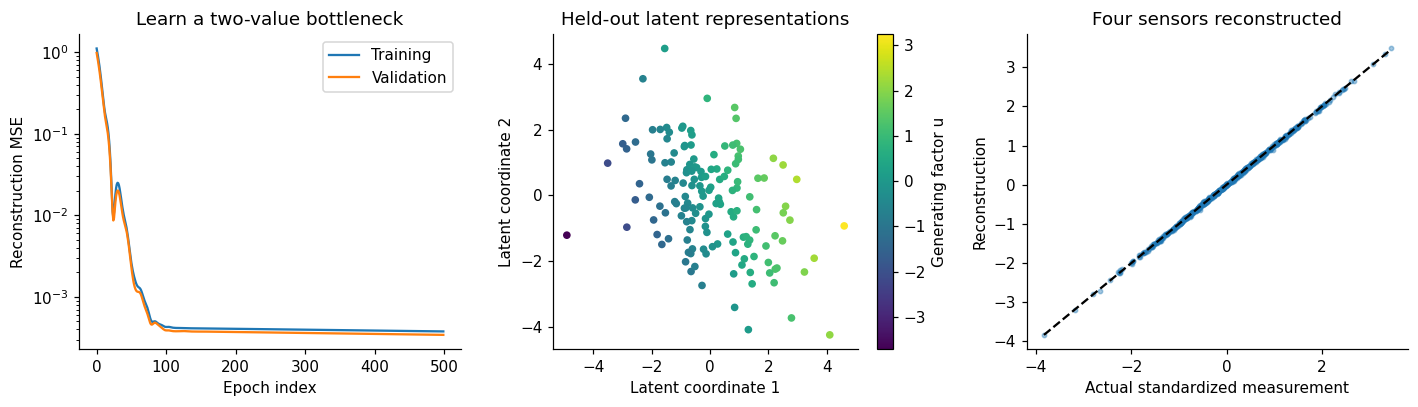

In [9]:
with torch.no_grad():
    test_z = encoder(test_x)
    reconstructed = decoder(test_z)
    test_mse = F.mse_loss(reconstructed, test_x).item()
    baseline_mse = F.mse_loss(torch.zeros_like(test_x), test_x).item()
assert test_z.shape == (len(test_x), 2)
assert torch.isfinite(test_z).all() and torch.isfinite(reconstructed).all()
assert test_mse < baseline_mse
print(f'Held-out reconstruction MSE: {test_mse:.6f}')
print(f'Training-mean baseline MSE: {baseline_mse:.6f}')
print('First standardized input:', test_x[0].tolist())
print('Its two latent coordinates:', test_z[0].tolist())
print('Its reconstruction:', reconstructed[0].tolist())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].semilogy(train_curve, label='Training')
axes[0].semilogy(val_curve, label='Validation')
axes[0].set(xlabel='Epoch index', ylabel='Reconstruction MSE', title='Learn a two-value bottleneck')
axes[0].legend()
points = axes[1].scatter(test_z[:, 0], test_z[:, 1], c=test_factors[:, 0], cmap='viridis', s=16)
axes[1].set(xlabel='Latent coordinate 1', ylabel='Latent coordinate 2', title='Held-out latent representations')
fig.colorbar(points, ax=axes[1], label='Generating factor u')
axes[2].scatter(test_x.flatten(), reconstructed.flatten(), s=8, alpha=0.4)
limits = [test_x.min().item(), test_x.max().item()]
axes[2].plot(limits, limits, '--', color='black')
axes[2].set(xlabel='Actual standardized measurement', ylabel='Reconstruction', title='Four sensors reconstructed')
fig.tight_layout()
plt.show()

## What the experiments establish

The embedding table learns relationships supplied by six category labels and supports nearest-neighbor lookup among those categories. It has no trained representation for an unknown ID. The encoder instead computes a representation for a new four-feature input, and its two-value bottleneck reconstructs held-out synthetic measurements better than a constant baseline.

Neither result establishes general language understanding or superiority to simpler dimensionality reduction methods. Coordinate axes are arbitrary, cosine ignores magnitude, and useful representations depend on the objective. Larger real tasks require held-out evaluation, dimension selection, and a deliberate strategy for rare and unknown categories.